# Creación del Modelo ML

## Características y suposiciones

### Segmentación de muestras (entrenamiento y test)

No podemos usar el train_test_split con la configuración por defecto porque mezcla filas al azar. Como nuestro dataset tiene un sentido temporal, podríamos estar entrenando el modelo con datos de cansancio de un jugador en marzon para predecir si se lesionó en noviembre. 

Para solucionarlo ordenaremos el DataFrame por fecha y haremos el corte manualmente, seleccionando los primeros meses como conjunto de entrenamiento y los últimos meses como conjunto de test, para ver si el modelo es capaz de predecir el futuro. 

### Desbalance de clases

Nuestro dataset tiene miles de filas pero muy pocas lesiones (en torno al 95% de los datos son 0s). Si le pasamos esto a un modelo normal, el modelo predecirá siempre 0 con el objetivo de lograr la máxima precisión posible. Para nuestro entrenador, un modelo que nunca le avise de una lesión es bastante inútil. 

Para solucionarlo usaremos un parámetros llamado class_weight='balanced', que nos permitirá ponderar los resultados y otorgar una puntuación al modelo si consigue predecir correctamente una lesión (1).

### Elección del modelo

Vamos a usar un RandomForestClassifier porque nuestro dataset sigue una relación no lineal: el riesgo de lesión sube si el valor de ACWR es muy bajo y si es muy alto (forma de U.)

Además no queremos decirle al entrenador "El jugador se va a lesionar hoy" sino más bien darle la probabilidad de que se lesione "Tiene un 65% de riesgo de lesión asi que usaremos predict_proba(). 

In [66]:
from consulta_sql import df_ml

In [67]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, recall_score, precision_score

## Preparación de los datos

In [68]:
df_ml.head()

,ID_Jugador,Fecha,Lesion,carga_aguda,carga_cronica,acwr,media_sueno_3d,es_visitante,alerta_sueno
0,JUG_01,2025-09-28,0.0,319.04,94.48,3.38,8.43,1,0
1,JUG_02,2025-09-28,0.0,0.00,122.98,0.00,7.80,1,0
2,JUG_03,2025-09-28,0.0,0.00,142.40,0.00,7.90,1,0
3,JUG_04,2025-09-28,0.0,62.21,162.68,0.38,7.07,1,0
4,JUG_05,2025-09-28,0.0,281.27,103.18,2.73,8.67,0,0


### Creación de matrices y separación de muestras

In [69]:
# Ordenar por fecha
df_ml = df_ml.sort_values("Fecha")

#  Separación de predictores y target
X = df_ml[["carga_aguda", "carga_cronica", "acwr", "media_sueno_3d", "es_visitante", "alerta_sueno"]]
y = df_ml[["Lesion"]]

In [70]:
# Definición del índice de corte
indice_corte = int(len(df_ml) * 0.8)

# Separación de matrices
# Datos del pasado (Para entrenar)
X_train = X.iloc[:indice_corte]
y_train = y.iloc[:indice_corte]

# Datos del futuro (Para examinar al modelo)
X_test = X.iloc[indice_corte:]
y_test = y.iloc[indice_corte:]

## Creación del modelo

In [71]:
# 1. Crear el modelo 
modelo_rf = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42 # Reproducibilidad
)

# 2. Entrenar el modelo
modelo_rf.fit(X_train, y_train)

# 3. Testear en datos nuevos (meses futuros)
probabilidades_totales = modelo_rf.predict_proba(X_test)

# 4. Nos quedamos con la columna de riesgo de lesión
riesgo_lesion_test = probabilidades_totales[:, 1]

# 5. Mostramos resultados
print("Primeras 5 predicciones de riesgo de lesión:", riesgo_lesion_test[:5])

c:\Users\ronge\Desktop\PROGRAMACION\DATA SCIENCE\Proyectos SQL\Analisis Lesiones\venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Primeras 5 predicciones de riesgo de lesión: [0.   0.02 0.   0.06 0.  ]


## Evaluación del modelo


In [72]:
# 1. Obtener las decisiones finales del modelo
y_pred = modelo_rf.predict(X_test)

# 2. Reporte
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=['Sano (0)', 'Lesión (1)']))

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    Sano (0)       0.95      1.00      0.97       608
  Lesión (1)       0.00      0.00      0.00        31

    accuracy                           0.95       639
   macro avg       0.48      0.50      0.49       639
weighted avg       0.91      0.95      0.93       639



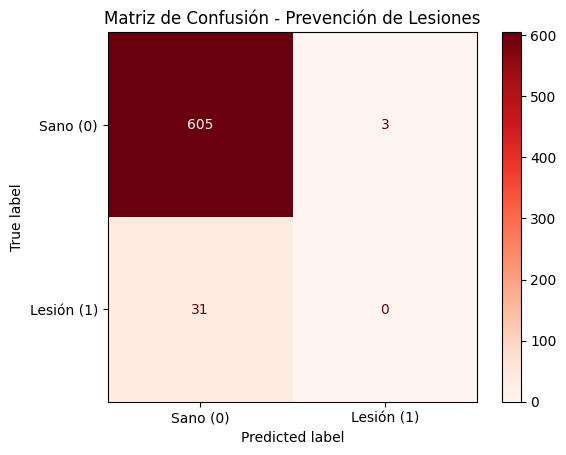

In [73]:
# 3. Dibujar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano (0)', 'Lesión (1)'])
disp.plot(cmap='Reds')
plt.title("Matriz de Confusión - Prevención de Lesiones")
plt.show()

Vemos que el recall, la métrica que queremos máximizar y que hace referencia a la capacidad del modelo de encontrar todos los casos positivos existentes (TP / (TP + FP)), es muy bajo (nulo). Esto puede deberse: 
- La probabilidad de padecer una lesión es muy baja (incluso durmiendo poco o viajando) por lo que el modelo se ajusta a predecir que no exiten lesiones para aumentar la probabilidad. 
- El modelo es sencillo. Tiene los hiperparámetros por defecto. 

Hemos probado a aumentar la probabilidad de lesión y las penalizaciones por viaje y carencia de sueño y no ha funcionado asi que procedemos al ajuste de hiperparámetros. 

In [74]:
# 1. Definimos las opciones para probar
param_grid = {
    'n_estimators': [100, 200],        # Número de árboles
    'max_depth': [None, 10, 20],       # Profundidad máxima de cada árbol 
    'min_samples_leaf': [1, 2, 4],     # Mínimo de datos por hoja 
    'class_weight': ['balanced',       # El estándar
                     {0: 1, 1: 10},    # Forzamos: Una lesión vale 10 veces más que un sano
                     {0: 1, 1: 20}]    # Forzamos: Una lesión vale 20 veces más
}

# 2. Configuración del Cross-Validation Temporal
tscv = TimeSeriesSplit(n_splits=3)

# 3. El GridSearch
# Scoring -> Recall, la métrica que quremos maximizar.
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring='recall', 
    n_jobs=-1,       
    verbose=1
)

grid_search.fit(X_train, y_train)

# 4. Resultados
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor Recall en validación: {grid_search.best_score_:.2f}")

# 5. Guardamos el mejor modelo en nuestra variable
mejor_modelo = grid_search.best_estimator_

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Mejores parámetros encontrados: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100}
Mejor Recall en validación: 0.17


c:\Users\ronge\Desktop\PROGRAMACION\DATA SCIENCE\Proyectos SQL\Analisis Lesiones\venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


--- REPORTE DEL MODELO OPTIMIZADO (GridSearch) ---
              precision    recall  f1-score   support

    Sano (0)       0.96      0.90      0.93       608
  Lesión (1)       0.11      0.26      0.16        31

    accuracy                           0.87       639
   macro avg       0.54      0.58      0.54       639
weighted avg       0.92      0.87      0.89       639



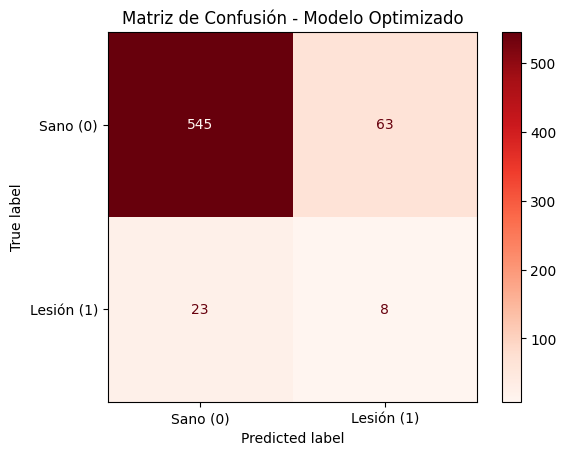

In [ ]:
# Predecir con el modelo optimizado.
probs_mejoradas = mejor_modelo.predict_proba(X_test)[:, 1]

y_pred_optimizado = mejor_modelo.predict(X_test)

print("--- REPORTE DEL MODELO OPTIMIZADO (GridSearch) ---")
print(classification_report(y_test, y_pred_optimizado, target_names=['Sano (0)', 'Lesión (1)']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_optimizado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano (0)', 'Lesión (1)'])
disp.plot(cmap='Reds')
plt.title("Matriz de Confusión - Modelo Optimizado")
plt.show()


Gracias al ajuste hemos conseguido aumentar el recall al 26% pero sigue sin ser suficiente para un contexto como el nuestro: nuestro modelo solo predeciría correctamente que 1 de cada 4 lesiones. Nuestro objetivo final pues, es conseguir aumentar esa métrica a cambio de sacrificar la de la precisión: es preferible dejar descansar a alguien que igual no se lesionaba que sacar a jugar a alguien que si tenía probabilidad de lesión. 

Para ello, vamos a modificar el umbral de decisión de modelo: en vez de dividir al 50% probaremos umbrales más bajos para detectar mejor las lesiones. 

--- BUSCANDO EL UMBRAL PERFECTO ---
Umbral 0.15: Recall = 0.94 | Precision = 0.10
Umbral 0.2: Recall = 0.74 | Precision = 0.08
Umbral 0.25: Recall = 0.61 | Precision = 0.08
Umbral 0.3: Recall = 0.58 | Precision = 0.09

--- REPORTE FINAL DEFINITIVO ---
              precision    recall  f1-score   support

    Sano (0)       0.98      0.59      0.74       608
  Lesión (1)       0.08      0.74      0.15        31

    accuracy                           0.60       639
   macro avg       0.53      0.67      0.44       639
weighted avg       0.93      0.60      0.71       639



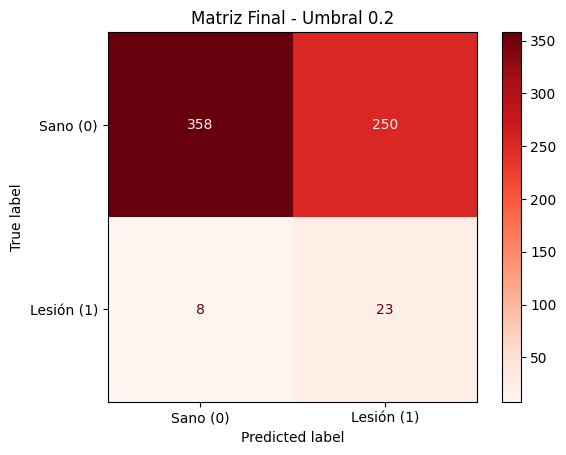

In [79]:
# Probamos varios cortes manuales
umbrales = [0.15, 0.20, 0.25, 0.30]

print("--- BUSCANDO EL UMBRAL PERFECTO ---")
for umbral in umbrales:
    preds_temp = (probs_mejoradas >= umbral).astype(int)
    recall = recall_score(y_test, preds_temp)
    precision = precision_score(y_test, preds_temp)
    f1 = 2 * (precision * recall) / (precision + recall)
    
    print(f"Umbral {umbral}: Recall = {recall:.2f} | Precision = {precision:.2f}")

# Elige el umbral que te dé un Recall > 0.60 (o el más alto posible)
# Sustituye 0.20 por el valor ganador de arriba
umbral_ganador = 0.20 

y_pred_finalisimo = (probs_mejoradas >= umbral_ganador).astype(int)

print("\n--- REPORTE FINAL DEFINITIVO ---")
print(classification_report(y_test, y_pred_finalisimo, target_names=['Sano (0)', 'Lesión (1)']))

# Matriz de confusión final
cm = confusion_matrix(y_test, y_pred_finalisimo)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano (0)', 'Lesión (1)'])
disp.plot(cmap='Reds')
plt.title(f"Matriz Final - Umbral {umbral_ganador}")
plt.show()

!Lo conseguimos! Aunque a veces dejaremos descansar a alguien con poca probabilidad de lesión, nos aseguremso que 3 de cada 4 veces que alguien tiene probabilidad de lesionarse permanezca en el banquillo. 

Ahora pasamos el df a csv para luego poder llevarlo a Power BI: 

In [85]:
# 1. Recuperamos el punto donde cortamos los datos (el 80%)
indice_corte = int(len(df_ml) * 0.8)

# 2. Creamos un NUEVO DataFrame solo con la parte del Test (el futuro)
df_resultados = df_ml.iloc[indice_corte:].copy()

# 3. AHORA SÍ: Las dimensiones coinciden (639 filas vs 639 predicciones)
df_resultados['Riesgo_Lesion_%'] = (probs_mejoradas * 100).round(2)
df_resultados['Alerta_Modelo'] = y_pred_finalisimo

# 4. Limpieza final para Power BI (Seleccionamos solo lo útil)
columnas_powerbi = [
    'ID_Jugador', 
    'Fecha', 
    'carga_aguda', 
    'carga_cronica', 
    'acwr', 
    'media_sueno_3d', 
    'es_visitante', 
    'Lesion',            
    'Riesgo_Lesion_%',   
    'Alerta_Modelo'     
]

df_exportar = df_resultados[columnas_powerbi]

# 5. Exportar a CSV
nombre_archivo = 'dataset_powerbi_casademont.csv'
df_exportar.to_csv('dataset_powerbi_casademont.csv', index=False, sep=';', decimal=',')

print(f"¡Solucionado! Archivo '{nombre_archivo}' generado con {len(df_exportar)} filas.")
print(df_exportar.head())

¡Solucionado! Archivo 'dataset_powerbi_casademont.csv' generado con 639 filas.
     ID_Jugador      Fecha  carga_aguda  carga_cronica  acwr  media_sueno_3d  \
2559     JUG_10 2026-03-17         0.00          96.38  0.00            8.07   
2557     JUG_08 2026-03-17        66.87          69.38  0.96            8.00   
2555     JUG_06 2026-03-17        48.46         109.75  0.44            7.83   
2554     JUG_05 2026-03-17       193.51         143.29  1.35            8.33   
2553     JUG_04 2026-03-17         0.00          84.30  0.00            8.47   

      es_visitante  Lesion  Riesgo_Lesion_%  Alerta_Modelo  
2559             0     0.0             0.00              0  
2557             0     0.0            28.76              1  
2555             0     0.0             6.62              0  
2554             0     0.0            37.35              1  
2553             0     0.0             0.00              0  
